In [1]:
import pickle as pkl
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.corpus import brown
from nltk import download
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import random
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import json

torch.manual_seed(42)

In [2]:
import importlib
import enc_dec_lstm
importlib.reload(enc_dec_lstm)
from enc_dec_lstm import Encoder_Decoder_Model

In [3]:
if torch.cuda.is_available():
	device = torch.device("cuda")
elif torch.xpu.is_available():
	device = torch.device("xpu")
else:
	device = torch.device("cpu")
device

device(type='cpu')

In [4]:
with open('../data/test_data.pkl', 'rb') as f:
    test_data = pkl.load(f)

In [5]:
with open('tokenizer/word2idx.json', 'r') as f:
    word2idx = json.load(f)
    idx2word = {v: k for k, v in word2idx.items()}
with open('tokenizer/tag2idx.json', 'r') as f:
    tag2idx = json.load(f)
    idx2tag = {v: k for k, v in tag2idx.items()}
with open("tokenizer/word_embeddings.pt", "rb") as f:
    train_embeddings = torch.load(f)

In [6]:
vocab_size = len(word2idx)
tag_size = len(tag2idx)

In [7]:
class POSTagDataset(Dataset):
    def __init__(self, sentences):
        self.data = []
        for sent in sentences:
            words, tags = zip(*sent)
            
            word_ids = [word2idx.get(w, 1) for w in words]
            tag_ids = [tag2idx.get(t, 0) if t in tag2idx else 0 for t in tags]

            length = len(word_ids)

            self.data.append((torch.tensor(word_ids).to(device), torch.tensor(tag_ids).to(device), length))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

In [8]:
test_dataset = POSTagDataset(test_data)

In [9]:
batch_size=128
test_loader = DataLoader(test_dataset, batch_size=1)

In [11]:
epochs = 10
embed_dim = 300
hidden_dim = 256
model=Encoder_Decoder_Model(vocab_size, embed_dim, hidden_dim, tag_size, train_embeddings).to(device)
lr=0.001
model.load_state_dict(torch.load(f'models/encoder_decoder_model_{lr}lr_{batch_size}bs_{epochs}epochs.pth', map_location=device))

<All keys matched successfully>

In [18]:
preds=[]
actuals=[]

In [19]:
count=-100

In [ ]:
model.eval()
with torch.no_grad():
    for test_batch in tqdm(test_loader, desc="Testing", total=len(test_loader)):
        words_batch, tags_batch, length_batch = test_batch
        input_seq = words_batch
        output_tags = model.generate(input_seq)
        tags=[[idx2tag[idx.item()] for idx in output_tags[i]] for i in range(len(output_tags))]
        preds+=tags[0]
        actuals+=[idx2tag[idx.item()] for idx in tags_batch[0]]
        if count==0:
            break
        count-=1

Testing: 100%|██████████| 5734/5734 [00:21<00:00, 261.12it/s]


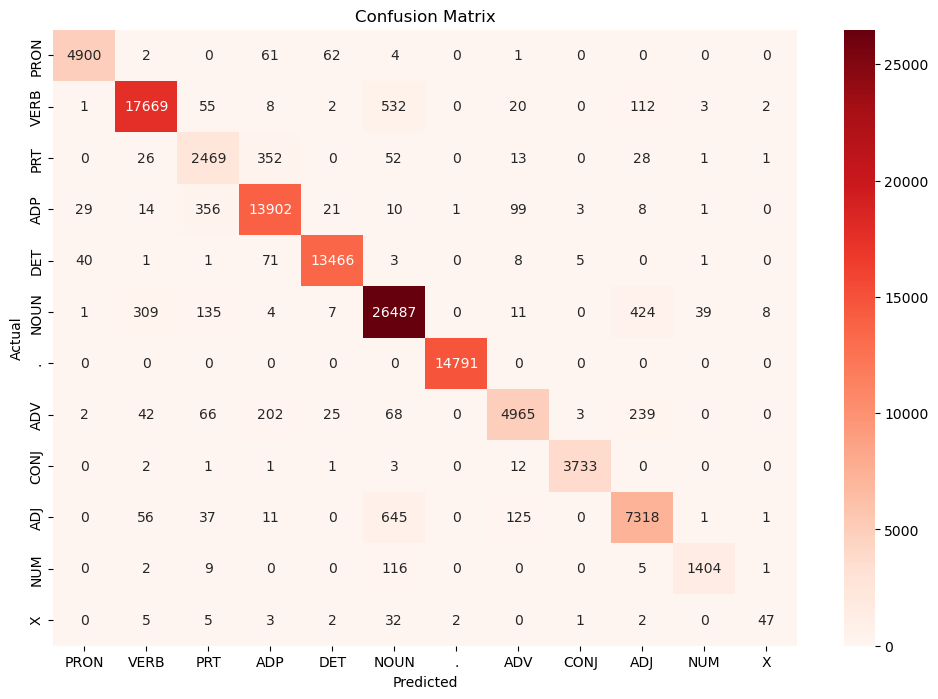

In [25]:
confusion_matrix_data = confusion_matrix(actuals, preds, labels=list(tag2idx.keys())[:-1])
plt.figure(figsize=(12, 8))
sns.heatmap(
    confusion_matrix_data,
    annot=True,
    cmap="Reds",
    fmt="d",
    xticklabels=list(tag2idx.keys())[:-1],
    yticklabels=list(tag2idx.keys())[:-1],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

In [24]:
print(classification_report(
    actuals, preds, labels=list(tag2idx.keys())[:-1], digits=4
))

              precision    recall  f1-score   support

        PRON     0.9853    0.9742    0.9797      5030
        VERB     0.9747    0.9601    0.9673     18404
         PRT     0.7878    0.8392    0.8127      2942
         ADP     0.9512    0.9625    0.9568     14444
         DET     0.9912    0.9904    0.9908     13596
        NOUN     0.9476    0.9658    0.9566     27425
           .     0.9998    1.0000    0.9999     14791
         ADV     0.9450    0.8847    0.9139      5612
        CONJ     0.9968    0.9947    0.9957      3753
         ADJ     0.8995    0.8931    0.8963      8194
         NUM     0.9683    0.9135    0.9401      1537
           X     0.7833    0.4747    0.5912        99

    accuracy                         0.9596    115827
   macro avg     0.9359    0.9044    0.9167    115827
weighted avg     0.9599    0.9596    0.9596    115827



In [ ]:
import os
os._exit(0)

: 